# AAV9 viabilité — Potts : λ = 0 vs CV sur λ

Même procédé que `AAV5_SEL_potts_regression.ipynb` (parties 1 et 2), appliqué à la **viabilité
AAV9** (`aav9.csv`, 68 776 variants, `target` = log enrichment réel, `error` constante) pour
comparer les résultats à ceux d'AAV5.

Différence structurelle avec AAV5 : ici `n = 68 776 > p = 8 541` (régime n > p), le fit se fait
sur **toutes** les lignes du train (pas de sous-échantillonnage), et `error` est constante donc
pas de pondération inverse-variance. Split `train_test_split(test_size=0.5, random_state=0)` —
le même qu'`AAV9_potts_regression.ipynb`.

Deux fits sur `idx_train`, évalués sur `idx_test` :
- **λ = 0** : OLS minimum-norm (`fit_weights_potts_from_data(..., lam=0)`).
- **CV** : ridge, λ choisi par CV 5-fold (`lam=None`, grille `np.logspace(-1, 2, 30)` par défaut).

Référence : la GT Potts du projet (`load_{F,J}_viab_aav9_potts`, = fit CV sur données complètes).

In [1]:
import sys, os
from pathlib import Path

# robust lib path: walk up to Modelization_V2/ (hardcoded ../../lib resolves to V1's pip copy
# from this subfolder -- and V1's RegressionV1 has no `lam` argument, cf. session brief)
_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if p.name == "Modelization_V2")
sys.path.insert(0, str(_root / "lib"))
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import RegressionV1 as R
from analysisV1 import AA_LABELS, pearson, topk_recovery
from initialize_weights import load_F_viab_aav9_potts, load_J_viab_aav9_potts
assert "Modelization_V2" in R.__file__, R.__file__
print(R.message)

CSV = Path("aav9.csv") if Path("aav9.csv").exists() else _root / "notebooks/notebooks/Viability/aav9.csv"
df = pd.read_csv(CSV)
L, A = int(df["sequence"].str.len().unique()[0]), len(AA_LABELS)
assert sorted(set("".join(df["sequence"]))) == AA_LABELS

lut = np.zeros(256, dtype=np.int64)
for i, aa in enumerate(AA_LABELS):
    lut[ord(aa)] = i
seq_matrix = lut[np.frombuffer("".join(df["sequence"]).encode("ascii"), np.uint8)].reshape(len(df), L)
target = df["target"].to_numpy(np.float64)
print(f"{len(df):,} variants  |  seq_matrix {seq_matrix.shape}  |  "
      f"error {'constante' if df['error'].nunique() == 1 else 'variable'}")

idx_train, idx_test = train_test_split(np.arange(len(df)), test_size=0.5, random_state=0)


def score_FJ(seq, F, J):
    F, J = np.asarray(F), np.asarray(J)
    Fp = F[seq, np.arange(L)].sum(axis=1).astype(np.float64)
    Jp = np.zeros(len(seq), dtype=np.float64)
    for i in range(L):
        for j in range(i + 1, L):
            Jp += J[i, j, seq[:, i], seq[:, j]]
    return Fp + Jp

file regression 1.5
68,776 variants  |  seq_matrix (68776, 7)  |  error constante


/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Fits sur `idx_train`, évaluation sur `idx_test`

In [2]:
LAMBDAS = np.logspace(-1, 2, 30)     # grille CV par défaut de fit_weights_potts_from_data

fits = {}
for tag, lam in [("lam0", 0.0), ("cv", None)]:
    F, J, rank, info = R.fit_weights_potts_from_data(
        seq_matrix[idx_train], target[idx_train],
        lambdas_grid=LAMBDAS, k_folds=5, seed=0, verbose=True, lam=lam)
    F, J = np.asarray(F), np.asarray(J)
    pred_test = score_FJ(seq_matrix[idx_test], F, J)
    fits[tag] = dict(
        F=F, J=J, lam=info["lam"], rank=int(rank),
        cv_mse=np.asarray(info["cv_mse"]) if info["cv_mse"] is not None else None,
        lambdas=np.asarray(info["lambdas_grid"]) if info["lambdas_grid"] is not None else None,
        pred_test=pred_test, r_test=pearson(target[idx_test], pred_test),
    )
    print(f"  [{tag}] lambda={fits[tag]['lam']:.4g}  rank={fits[tag]['rank']}/{L*A + L*(L-1)//2*A*A + 1}"
          f"  held-out r = {fits[tag]['r_test']:+.3f}\n")

# référence projet : GT Potts (fit CV sur données complètes) + son score held-out pour comparaison
F_gt, J_gt = np.asarray(load_F_viab_aav9_potts()), np.asarray(load_J_viab_aav9_potts())
r_gt_test = pearson(target[idx_test], score_FJ(seq_matrix[idx_test], F_gt, J_gt))
var_y_tr = float(np.var(target[idx_train]))
print(f"  [GT projet]  held-out r = {r_gt_test:+.3f}   (fit sur données complètes -> inclut idx_test, optimiste)")
print(f"  Var(target[train]) = {var_y_tr:.3f}")

pd.DataFrame({t: {"lambda": f["lam"], "rank": f["rank"], "r_test": f["r_test"]}
              for t, f in fits.items()}).T

lam=0 -> minimum-norm unregularized (lstsq) fit, CV skipped


Design matrix rank: 7715 / 8541 features (34388 obs)
  [lam0] lambda=0  rank=7715/8541  held-out r = +0.838



Design matrix rank: 7715 / 8541 features (34388 obs)
  NOTE: rank-deficient design (p > n) -- ridge is not just a preference, the unregularized fit below is non-unique.


Ridge CV (aav9):   0%|          | 0/5 [00:00<?, ?it/s]

Ridge CV (aav9):  20%|██        | 1/5 [02:00<08:00, 120.05s/it]

...

Ridge CV (aav9):  80%|████████  | 4/5 [11:27<03:00, 180.30s/it]

Ridge CV (aav9): 100%|██████████| 5/5 [14:32<00:00, 181.99s/it]

Best lambda: 23.9503


  [cv] lambda=23.95  rank=7715/8541  held-out r = +0.847

  [GT projet]  held-out r = +0.887   (fit sur données complètes -> inclut idx_test, optimiste)
  Var(target[train]) = 17.699


,lambda,rank,r_test
lam0,0.000000,7715.0,0.837882
cv,23.950266,7715.0,0.846667


## 2. Diagnostic

Courbe CV MSE vs λ (pour le fit CV ; `Var(y)` = MSE d'un modèle constant). Puis score GT (F + J)
vs `target` réel sur `idx_test` (hexbin log) pour λ=0, CV et la GT projet.

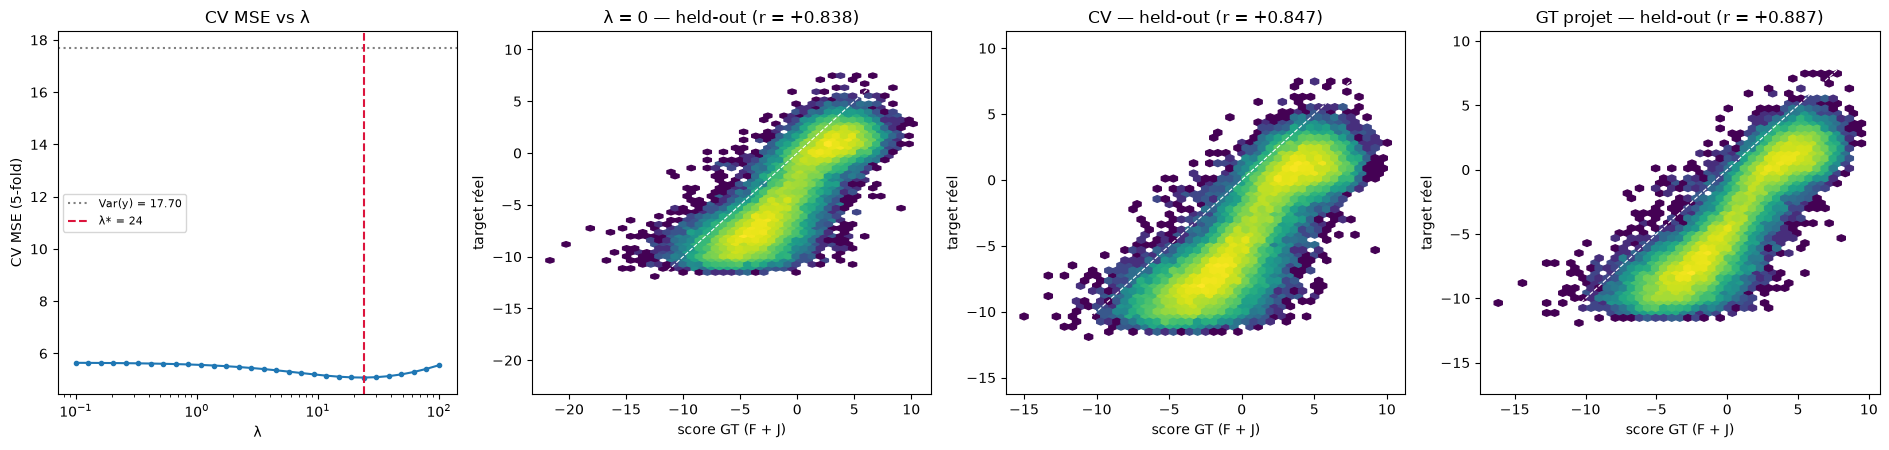

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(19, 4.6))

ax = axes[0]
fc = fits["cv"]
ax.plot(fc["lambdas"], fc["cv_mse"], "o-", ms=3)
ax.axhline(var_y_tr, color="grey", ls=":", label=f"Var(y) = {var_y_tr:.2f}")
ax.axvline(fc["lam"], color="crimson", ls="--", label=f"λ* = {fc['lam']:.2g}")
mono = np.all(np.diff(fc["cv_mse"]) <= 1e-9)
ax.set(xscale="log", xlabel="λ", ylabel="CV MSE (5-fold)",
       title="CV MSE vs λ" + ("  (monotone ↓)" if mono else ""))
ax.legend(fontsize=8)

for ax, (lbl, F, J, r) in zip(axes[1:], [
        ("λ = 0",     fits["lam0"]["F"], fits["lam0"]["J"], fits["lam0"]["r_test"]),
        ("CV",        fits["cv"]["F"],   fits["cv"]["J"],   fits["cv"]["r_test"]),
        ("GT projet", F_gt, J_gt, r_gt_test)]):
    p = score_FJ(seq_matrix[idx_test], F, J)
    yv = target[idx_test]
    ax.hexbin(p, yv, gridsize=45, bins="log", mincnt=1, cmap="viridis")
    lo, hi = min(p.min(), yv.min()), max(p.max(), yv.max())
    ax.plot([lo, hi], [lo, hi], "w--", lw=0.8)
    ax.set(title=f"{lbl} — held-out (r = {r:+.3f})",
           xlabel="score GT (F + J)", ylabel="target réel")
plt.tight_layout(); plt.show()

## 3. Poids F (profil) et J (couplages)

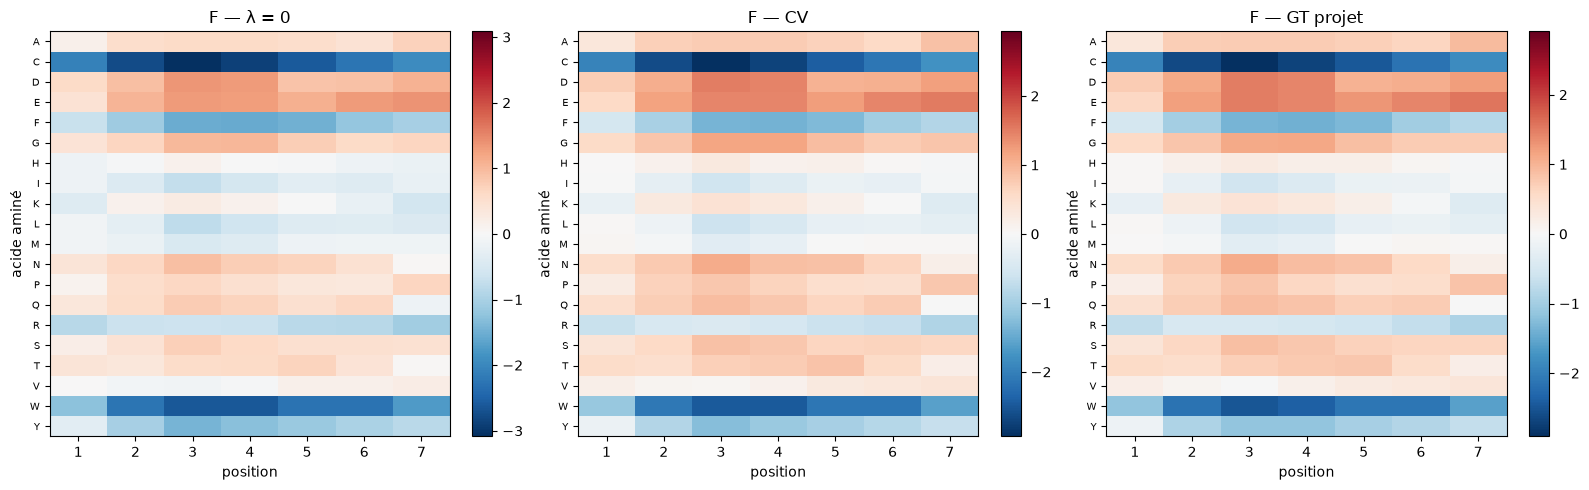

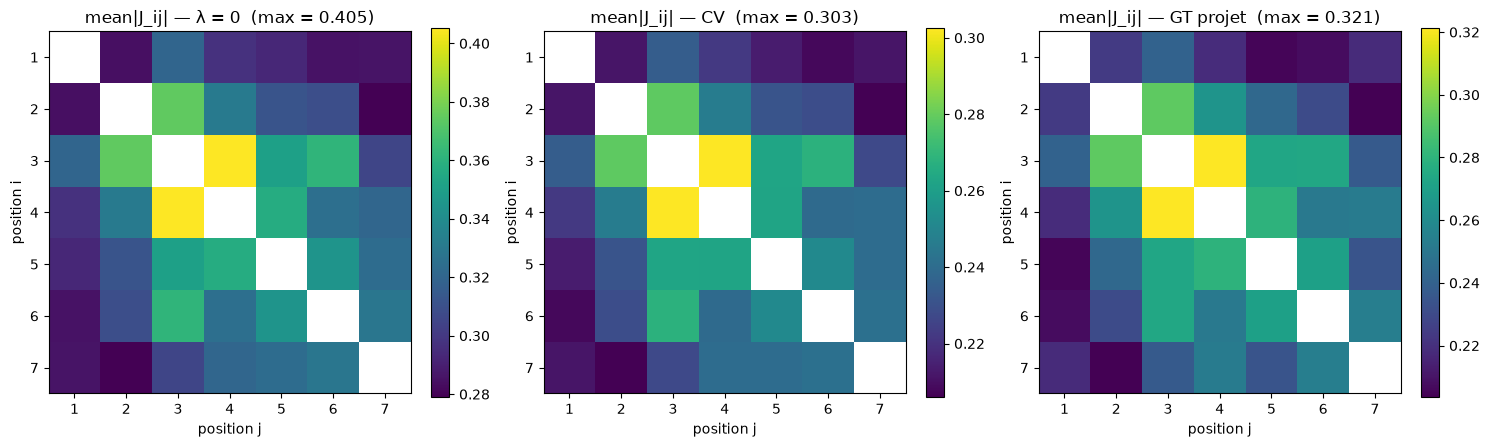

λ = 0      mean|F| = 0.7522   mean|J| = 0.2774   mean|J|/mean|F| = 0.369
CV         mean|F| = 0.7567   mean|J| = 0.2053   mean|J|/mean|F| = 0.271
GT projet  mean|F| = 0.7586   mean|J| = 0.2121   mean|J|/mean|F| = 0.280


In [4]:
panels = [("λ = 0", fits["lam0"]), ("CV", fits["cv"])]
panels_F = panels + [("GT projet", dict(F=F_gt, J=J_gt))]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (lbl, f) in zip(axes, panels_F):
    Fm = np.asarray(f["F"])
    vmax = np.abs(Fm).max() or 1.0
    im = ax.imshow(Fm, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(L)); ax.set_xticklabels(range(1, L + 1))
    ax.set_yticks(range(A)); ax.set_yticklabels(AA_LABELS, fontsize=7)
    ax.set(title=f"F — {lbl}", xlabel="position", ylabel="acide aminé")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, (lbl, f) in zip(axes, panels_F):
    Jabs = np.abs(np.asarray(f["J"])).mean(axis=(2, 3))
    off = Jabs.copy(); np.fill_diagonal(off, np.nan)
    im = ax.imshow(off, cmap="viridis")
    ax.set_xticks(range(L)); ax.set_xticklabels(range(1, L + 1))
    ax.set_yticks(range(L)); ax.set_yticklabels(range(1, L + 1))
    ax.set(title=f"mean|J_ij| — {lbl}  (max = {np.nanmax(off):.3f})",
           xlabel="position j", ylabel="position i")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

for lbl, f in panels_F:
    F, J = np.asarray(f["F"]), np.asarray(f["J"])
    print(f"{lbl:10s} mean|F| = {np.abs(F).mean():.4f}   mean|J| = {np.abs(J).mean():.4f}   "
          f"mean|J|/mean|F| = {np.abs(J).mean() / np.abs(F).mean():.3f}")

## 4. Distribution du score GT (F + J) sur la librairie AAV9 (68 776 variants)

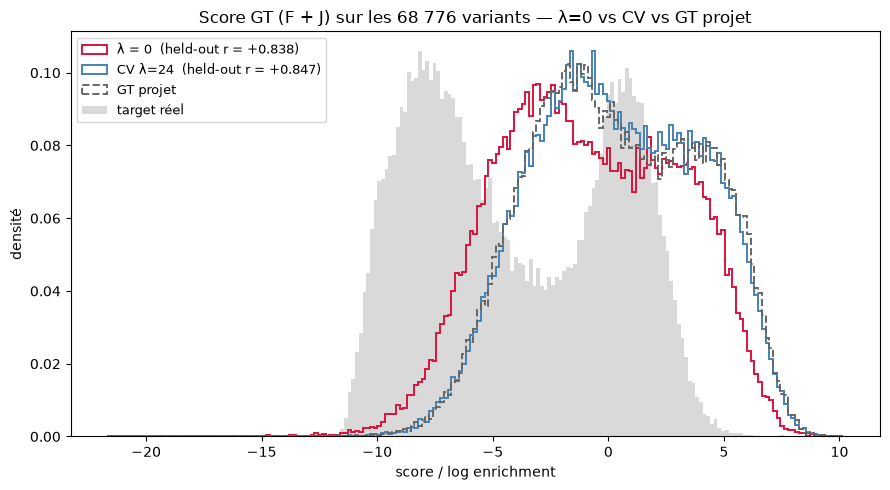

In [5]:
s_lam0 = score_FJ(seq_matrix, fits["lam0"]["F"], fits["lam0"]["J"])
s_cv   = score_FJ(seq_matrix, fits["cv"]["F"],   fits["cv"]["J"])
s_gt   = score_FJ(seq_matrix, F_gt, J_gt)

fig, ax = plt.subplots(figsize=(9, 5))
bins = np.linspace(min(s_lam0.min(), s_cv.min(), s_gt.min()),
                   max(s_lam0.max(), s_cv.max(), s_gt.max()), 200)
ax.hist(s_lam0, bins=bins, density=True, histtype="step", lw=1.4, color="crimson",
        label=f"λ = 0  (held-out r = {fits['lam0']['r_test']:+.3f})")
ax.hist(s_cv, bins=bins, density=True, histtype="step", lw=1.4, color="steelblue",
        label=f"CV λ={fits['cv']['lam']:.2g}  (held-out r = {fits['cv']['r_test']:+.3f})")
ax.hist(s_gt, bins=bins, density=True, histtype="step", lw=1.4, color="0.4", ls="--",
        label="GT projet")
ax.hist(target, bins=bins, density=True, color="0.85", zorder=0, label="target réel")
ax.set(xlabel="score / log enrichment", ylabel="densité",
       title="Score GT (F + J) sur les 68 776 variants — λ=0 vs CV vs GT projet")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## 5. Comparaison chiffrée

- `r held-out` : λ=0 vs CV vs GT projet (attention : la GT projet est fittée sur les données
  complètes, `idx_test` inclus → son `r` est optimiste, pas directement comparable).
- `r(F, .)` / `r(J, .)` : à quel point les jeux de poids diffèrent.
- `r(score)` / `top-k ∩` : impact sur le **classement** des 68 776 variants.

In [6]:
def corr(a, b):
    return np.corrcoef(np.asarray(a).ravel(), np.asarray(b).ravel())[0, 1]

od = ~np.eye(L, dtype=bool)
F0, J0 = fits["lam0"]["F"], fits["lam0"]["J"]
Fc, Jc = fits["cv"]["F"],   fits["cv"]["J"]

comp = pd.DataFrame({
    "held-out r":      {"λ=0": fits["lam0"]["r_test"], "CV": fits["cv"]["r_test"], "GT projet": r_gt_test},
    "r(F vs λ=0)":     {"λ=0": 1.0, "CV": corr(Fc, F0), "GT projet": corr(F_gt, F0)},
    "r(J vs λ=0), off-diag": {"λ=0": 1.0,
                              "CV": corr(Jc[od], J0[od]), "GT projet": corr(J_gt[od], J0[od])},
    "r(score vs λ=0)": {"λ=0": 1.0, "CV": corr(s_cv, s_lam0), "GT projet": corr(s_gt, s_lam0)},
}).T.round(3)
display(comp)

print("recouvrement top-k du classement des 68 776 variants :")
for k in (100, 500, 2000):
    print(f"  top-{k:>4}:  λ=0 ∩ CV = {topk_recovery(s_lam0, s_cv, k=k):.3f}   "
          f"λ=0 ∩ GT = {topk_recovery(s_lam0, s_gt, k=k):.3f}   "
          f"CV ∩ GT = {topk_recovery(s_cv, s_gt, k=k):.3f}")

,λ=0,CV,GT projet
held-out r,0.838,0.847,0.887
r(F vs λ=0),1.000,1.000,0.999
"r(J vs λ=0), off-diag",1.000,0.988,0.921
r(score vs λ=0),1.000,0.991,0.977


recouvrement top-k du classement des 68 776 variants :
  top- 100:  λ=0 ∩ CV = 0.790   λ=0 ∩ GT = 0.430   CV ∩ GT = 0.440
  top- 500:  λ=0 ∩ CV = 0.752   λ=0 ∩ GT = 0.500   CV ∩ GT = 0.564
  top-2000:  λ=0 ∩ CV = 0.831   λ=0 ∩ GT = 0.648   CV ∩ GT = 0.721


## 6. Résidus held-out

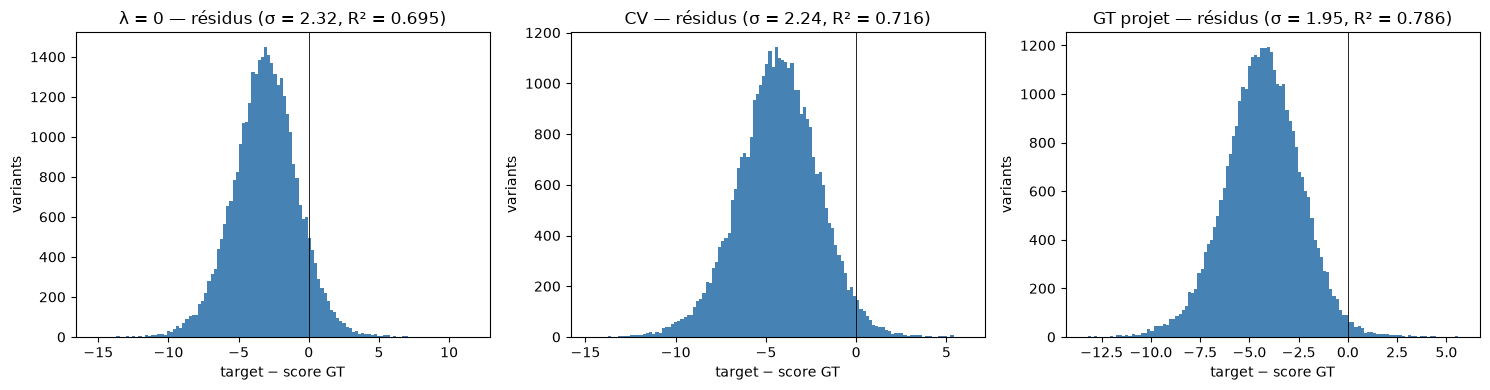

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (lbl, pred, r) in zip(axes, [
        ("λ = 0", fits["lam0"]["pred_test"], fits["lam0"]["r_test"]),
        ("CV",    fits["cv"]["pred_test"],   fits["cv"]["r_test"]),
        ("GT projet", score_FJ(seq_matrix[idx_test], F_gt, J_gt), r_gt_test)]):
    resid = target[idx_test] - pred
    ax.hist(resid, bins=120, color="steelblue")
    ax.axvline(0, color="k", lw=0.6)
    ax.set(title=f"{lbl} — résidus (σ = {resid.std():.2f}, R² = {1 - resid.var()/var_y_tr:.3f})",
           xlabel="target − score GT", ylabel="variants")
plt.tight_layout(); plt.show()